# Capturing Knowledge about Drug-Drug Interactions to Enhance Treatment Effectiveness

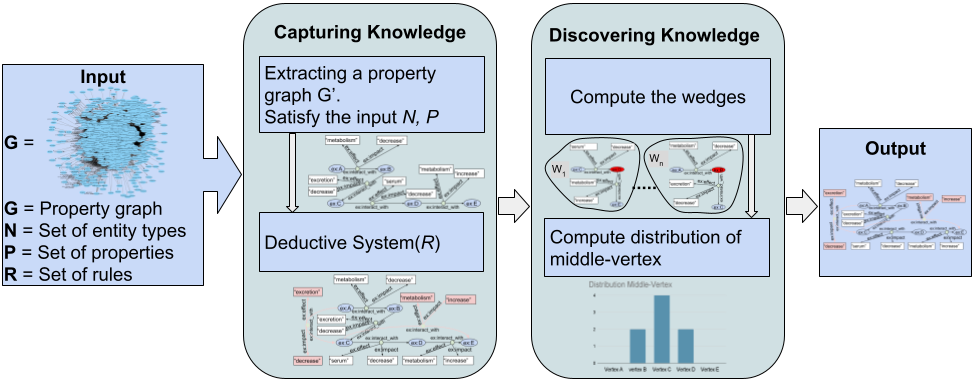

In [3]:
from IPython.display import Image, display
display(Image(filename="Approach_03.png"))

In [1]:
import auxiliar_wedge
import ipywidgets as widgets
from IPython.display import clear_output

from ipywidgets import GridspecLayout
import pandas as pd
import warnings

In [2]:
class Treatment():
    
    def set_value(self, union, set_dsd_label):
        self.union = union
        self.set_dsd_label = set_dsd_label
        
    def set_value_frequency(self, dict_frequency):
        self.dict_frequency = dict_frequency
        
    def set_graph_enriched(self, graph_ddi):
        self.graph_ddi = graph_ddi
    
    def set_toxicity_rate(self, toxicity_rate, toxicity_rate_k):
        self.toxicity_rate = toxicity_rate
        self.toxicity_rate_k = toxicity_rate_k
        
    def __init__(self):
        self.adverse_event = []
        self.union = pd.DataFrame()
        self.set_dsd_label = set()
        self.comorbidity_drug = set()
        self.set_DDIs = pd.DataFrame()
        self.dict_frequency = {}
        self.toxicity_rate = {}
        self.toxicity_rate_k = {}

class Drug():
    def construct(self, dict_cui_label):
        self.drug_cui = dict_cui_label
    
    def __init__(self):
        self.drug_cui = dict()

w = Treatment()
drug = Drug()

# Input

In [3]:
# drug_list = list(pd.read_csv('drug_list.csv').drugLabel.values)
df_cui = pd.read_csv('CUI_DrugBank.csv')
drug_list = list(df_cui.DrugName.unique())
# drug_list = [label.lower() for label in drug_list]
dict_drug_cui = dict(zip(df_cui.DrugName, df_cui.CUI_ID))
drug.construct(dict_drug_cui)

#### Input set of entities

In [4]:
drug_label1 = widgets.Combobox(
    # value='John',
    placeholder='Write a drug name',
    options=drug_list,
    description='Disease Drug:',
    ensure_option=True,
    disabled=False
)

drug_label2 = widgets.Combobox(
    placeholder='Write a drug name',
    options=drug_list,
    description='Comorbidity Drug:',
    ensure_option=True,
    disabled=False
)
button_cui1 = widgets.Button(description="Add Drug")
button_cui2 = widgets.Button(description="Add Drug")

def create_expanded_button(description, button_style):
    return widgets.Button(description=description, button_style=button_style,
                          layout=widgets.Layout(height='auto', width='auto'))

grid = GridspecLayout(3, 3, height='150px')
grid[0, 0] = drug_label1 # label_cui1
grid[0, 1] = button_cui1
grid[0, 2] = widgets.Text(value='', disabled=True)
grid[1, 0] = drug_label2 # label_cui2
grid[1, 1] = button_cui2
grid[1, 2] = widgets.Text(value='', disabled=True)
grid[2, 0] = create_expanded_button('Restart Drugs', 'danger')
grid[2, 2] = create_expanded_button("""Extract property graph G""", 'success')
display(grid)
#"C0008838","C0078257"],"Non_OncologicalDrugs":["C0028978", "C0074554", "C0009214"]}

GridspecLayout(children=(Combobox(value='', description='Disease Drug:', ensure_option=True, layout=Layout(gri…

In [6]:
def button_cui1_clicked(parm):
#     grid[0, 2:].value +=',' + grid[0, 0].value
#     grid[0, 0].value = ''
    
    grid[0, 2:].value +=',' + drug.drug_cui[grid[0, 0].value]
    grid[0, 0].value = ''
    
def button_cui2_clicked(parm):
    grid[1, 2:].value+=',' + drug.drug_cui[grid[1, 0].value]
    grid[1, 0].value = ''

def button_restart_clicked(parm):
    grid[0, 0].value = ''
    grid[0, 2:].value = ''
    grid[1, 0].value = ''
    grid[1, 2:].value = ''

def button_traverse_kg_clicked(parm):
    input_data = {"Input":{"OncologicalDrugs":[], "Non_OncologicalDrugs":[]}}
    input_data["Input"]["OncologicalDrugs"] = grid[0, 2:].value[1:].split(',')
    input_data["Input"]["Non_OncologicalDrugs"]= grid[1, 2:].value[1:].split(',')
#     input_data = {'Input': {'OncologicalDrugs': ['C0045093', 'C3657270'], 'Non_OncologicalDrugs': ['C0034665', 'C0008809', 'C0016860', 'C0060926']}}
#     input_data = {'Input': {'OncologicalDrugs': ['C3853921'], 'Non_OncologicalDrugs': ['C0286651', 'C0012010', 'C0016410', 'C0004147']}}
    print(input_data)
    union, set_dsd_label = auxiliar_wedge.load_data(input_data)
    w.set_value(union, set_dsd_label)


grid[0, 1].on_click(button_cui1_clicked)
grid[1, 1].on_click(button_cui2_clicked)
grid[2, 0].on_click(button_restart_clicked)
grid[2, 2].on_click(button_traverse_kg_clicked)

## Visualize graph with DDIs

In [7]:
button = widgets.Button(description="Visualize")
output = widgets.Output()
display(button, output)

def on_button_clicked(tfry):
    with output:
        clear_output(wait=True)
        display(auxiliar_wedge.create_graph_cytoscape(auxiliar_wedge.create_json_to_cytoscape(w.union, ''))) #dropdown_middle_vertex.value

button.on_click(on_button_clicked)

Button(description='Visualize', style=ButtonStyle())

Output()

# Visualize graph with Deduced DDIs

In [8]:
button = widgets.Button(description="Visualize")
output_1 = widgets.Output()
display(button, output_1)

def on_button_clicked(tfry):
    with output_1:
        clear_output(wait=True)
        graph_ddi, graph_json = auxiliar_wedge.get_graph_enriched(w.union, w.set_dsd_label)
        display(auxiliar_wedge.create_graph_cytoscape(graph_json)) #dropdown_middle_vertex.value

button.on_click(on_button_clicked)

Button(description='Visualize', style=ButtonStyle())

Output()

# Get DDI rate of drugs in a treatment with Oncological and Non-Oncological Drugs

In [9]:
output_6 = widgets.Output()
button_toxicity_rate = create_expanded_button('Distribution of Toxicity Rate', 'success')

def action_button_toxicity(parm):
    with output_6:
        warnings.filterwarnings("ignore")
        clear_output(wait=True)
        dict_wedge, df_wedge = auxiliar_wedge.discovering_knowledge(w.union, w.set_dsd_label)
        dropdown_middle_vertex.options=df_wedge
        w.set_toxicity_rate(dict_wedge['DDI_rate'], dict_wedge['pharmacokinetic_DDI_rate'])
        dict_wedge_basic, df_wedge_basic = auxiliar_wedge.evaluation_without_deduction(w.union, w.set_dsd_label)
        dropdown_middle_vertex_basic.options=df_wedge_basic
        df1 = pd.DataFrame(list(w.toxicity_rate.values()), index = w.toxicity_rate.keys(), columns=['Eval1'])
        for k,v in dict_wedge_basic['DDI_rate'].items():
            df1.at[k, 'Eval2'] = v
        auxiliar_wedge.comparision_distribution_wedge(df1, "Toxicity rate distribution", "Drug", "Toxicity rate")
#         auxiliar_wedge.wilcoxon_test(df1)
        
        df1 = pd.DataFrame(list(w.toxicity_rate_k.values()), index = w.toxicity_rate_k.keys(), columns=['Eval1'])
        for k,v in dict_wedge_basic['pharmacokinetic_DDI_rate'].items():
            df1.at[k, 'Eval2'] = v
        auxiliar_wedge.comparision_distribution_wedge(df1, "Pharmacokinetic toxicity rate distribution", "Drug", "Pharmacokinetic toxicity rate")
#         auxiliar_wedge.wilcoxon_test(df1)

button_toxicity_rate.on_click(action_button_toxicity)
display(button_toxicity_rate, output_6)

Button(button_style='success', description='Distribution of Toxicity Rate', layout=Layout(height='auto', width…

Output()

# Select the Middle-Vertex in Graph with DDIs Deduced 

In [10]:
dropdown_middle_vertex = widgets.Dropdown(options = {}, description='Middle-Vertex:')
display(dropdown_middle_vertex)

Dropdown(description='Middle-Vertex:', options={}, value=None)

# Visualize the wedges of the middle-vertex selected

In [11]:
button = widgets.Button(description="Visualize")
output_2 = widgets.Output()
display(button, output_2)

def on_button_clicked(tfry):
    with output_2:
        clear_output(wait=True)
#         graph_ddi = auxiliar_wedge.get_graph_enriched(w.union, w.set_dsd_label)
        display(auxiliar_wedge.create_graph_cytoscape(dropdown_middle_vertex.value)) #dropdown_middle_vertex.value

button.on_click(on_button_clicked)

Button(description='Visualize', style=ButtonStyle())

Output()

## Select the Middle-Vertex in Basic Graph

In [12]:
dropdown_middle_vertex_basic = widgets.Dropdown(options = {}, description='Middle-Vertex:')
display(dropdown_middle_vertex_basic)

Dropdown(description='Middle-Vertex:', options={}, value=None)

# Visualize the wedges of the middle-vertex selected

In [13]:
button = widgets.Button(description="Visualize")
output_3 = widgets.Output()
display(button, output_3)

def on_button_clicked(tfry):
    with output_3:
        clear_output(wait=True)
        display(auxiliar_wedge.create_graph_cytoscape(dropdown_middle_vertex_basic.value))

button.on_click(on_button_clicked)

Button(description='Visualize', style=ButtonStyle())

Output()

In [15]:
# dict_wedge_basic = auxiliar_wedge.evaluation_without_deduction(w.union, w.set_dsd_label)
# dict_wedge_basic

In [32]:
# dict_wedge, df_wedge = auxiliar_wedge.discovering_knowledge(w.union, w.set_dsd_label)
# dict_wedge['DDI_rate']
# dict_wedge['pharmacokinetic_DDI_rate']

{'nelfinavir': 0.16666666666666666,
 'mirtazapine': 0.0,
 'aripiprazole': 0.0,
 'methylphenidate': 0.0}

In [33]:
# dict_wedge['DDI_rate']


{'mirtazapine': 0.19047619047619047,
 'aripiprazole': 0.09523809523809523,
 'nelfinavir': 0.023809523809523808,
 'methylphenidate': 0.0}

In [34]:
# dict_wedge

{'DDI_rate': {'mirtazapine': 0.19047619047619047,
  'aripiprazole': 0.09523809523809523,
  'nelfinavir': 0.023809523809523808,
  'methylphenidate': 0.0},
 'most_DDI_drug': ['mirtazapine'],
 'pharmacokinetic_DDI_rate': {'nelfinavir': 0.16666666666666666,
  'mirtazapine': 0.0,
  'aripiprazole': 0.0,
  'methylphenidate': 0.0},
 'most_DDI_drug_pharmacokinetic': ['nelfinavir']}